In [2]:
import pandas as pd
from scipy.stats import hmean
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import matplotlib.colors as mcolors
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel, ConstantKernel as C
import colorsys

In [3]:
plt.style.use("default")

In [4]:
'''Load ability profiles'''
nature_profiles_df = pd.read_csv("data/ability_profiles_MaxAuxDiff=0_DupThresh=100.csv", index_col=0)
additional_profiles_df = pd.read_csv('data/additional_results_16June2026.csv', index_col=0)
ability_profiles_df = pd.concat([nature_profiles_df, additional_profiles_df], axis=0)

In [5]:
'''Compute reduced profiles with 1 score for each of 10 group of dimensions instead of 1 score for each of 18 dimensions'''
#We use the fact that each dimension code starts with the exact two letters that make up the code of the group it belongs to. Group SN is treated separately due to being the only group that contains exactly one dimension but with a third letter in the dimension code.
dimension_groups = list(set([name[:2] for name in ability_profiles_df.columns]))
dimension_groups.sort()
dimensions = list(ability_profiles_df.columns)
for dimension_group in dimension_groups:
    components = [dimension for dimension in dimensions if dimension[:2] == dimension_group]
    if len(components) >= 2:
        ability_profiles_df[dimension_group] = ability_profiles_df[components].apply(hmean, axis=1)
ability_profiles_df['SN'] = ability_profiles_df['SNs'].copy()
reduced_profiles_columns = list(dimension_groups)
reduced_profiles_df = ability_profiles_df[reduced_profiles_columns].copy()

In [6]:
"""Cross-reference ability profiles with model release dates"""
release_dates_df = pd.read_csv("data/release_dates.csv", index_col=0)
release_dates_df = release_dates_df[['Date de sortie']]
release_dates_df['Date de sortie'] = pd.to_datetime(release_dates_df['Date de sortie'])
reduced_profiles_df['Date'] = release_dates_df['Date de sortie']

C:\Users\Michel\AppData\Local\Temp\ipykernel_66824\3370102922.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  release_dates_df['Date de sortie'] = pd.to_datetime(release_dates_df['Date de sortie'])


In [7]:
"""Define the function used to compute which models are considered frontier models. That function should receive an entry where xs represent release dates and ys represent scores, with compatible ordering (i.e. xs[i] and ys[i] refering to the same model)
!!! I (Michel) am not sure about how this function handles cases where some models sharing the exact same release date surpass all previous models. In practice, this case did not happen during our analysis, but be aware of that subtelty if you intend to reuse that function."""
def frontier_indices(xs, ys):
    assert len(xs) == len(ys)
    sorted_order = np.argsort(xs)
    current_max = -np.inf
    front_original_indices = []
    for idx in sorted_order:
        if ys[idx] > current_max:
            current_max = ys[idx]
            front_original_indices.append(idx)
    return front_original_indices

In [8]:
group_full_names = {
    'AS': 'Attention and Scan',
    'CE': 'Comprehension and Expression',
    'CL': 'Conceptualisation, Learning and Abstraction',
    'MC': 'Metacognition and Critical Thinking',
    'MS': 'Mind Modelling and Social Cognition',
    'QL': 'Quantitative and Logical Reasoning',
    'SN': 'Spatial Reasoning and Navigation',
    'KN': 'Knowledge',
    'AT': 'Atypicality',
    'VO': 'Volume'
}

In [9]:
corporations = {'Babbage-002' : 'OpenAI',
                'Davinci-002' : 'OpenAI',
                'GPT-3.5-Turbo' : 'OpenAI',
                'GPT-4o' : 'OpenAI',
                'OpenAI o1-mini' : 'OpenAI',
                'OpenAI o1' : 'OpenAI',
                'LLaMA-3.2-1B-Instruct' : 'Meta',
                'LLaMA-3.2-3B-Instruct' : 'Meta',
                'LLaMA-3.2-11B-Instruct' : 'Meta',
                'LLaMA-3.2-90B-Instruct' : 'Meta',
                'LLaMA-3.1-405B-Instruct' : 'Meta',
                'DK-R1-Dist-Qwen-1.5B' : 'Qwen',
                'DK-R1-Dist-Qwen-7B' : 'Qwen',
                'DK-R1-Dist-Qwen-14B' : 'Qwen',
                'DK-R1-Dist-Qwen-32B' : 'Qwen',
                'Gemini-2.5-Flash' : 'Google',
                'Gemini-3.1-Flash' : 'Google',
                'Gemini-3.1-Pro' : 'Google',
                'LLaMA-4-17B-128E' : 'Meta',
                'GPT-5.2-Chat' : 'OpenAI',
                'OpenAI o3-mini' : 'OpenAI'}


In [10]:
corpo_color_map = {'OpenAI' : 'r',
                   'Meta' : 'b',
                   'Qwen' : 'g',
                   'Google' : 'purple'}

In [11]:
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.edgecolor': '#444444',
    'axes.linewidth': 0.8,
})

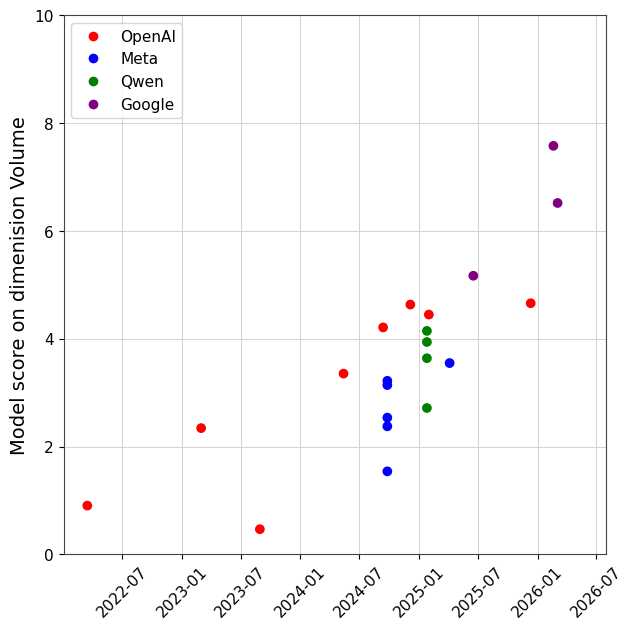

In [12]:
"""This cell generates fig 5 of our post"""
demand_groups = list(reduced_profiles_df.columns)
demand_groups.remove('Date')
release_dates = reduced_profiles_df['Date'].values
model_names = list(reduced_profiles_df.index)
xs = release_dates
ys = reduced_profiles_df['VO'].values
colors = [corpo_color_map[corporations[x]]  for x in model_names]
fig, ax = plt.subplots(1, 1, figsize=(7, 7), sharex=True, sharey=True)
ax.scatter(xs, ys, zorder=3, c=colors)
x_end = pd.Timestamp("2026-08-01")
ax.set_xlim(ax.get_xlim()[0], mdates.date2num(x_end))
xlim = ax.get_xlim()
xlim_dates = [d.replace(tzinfo=None) for d in mdates.num2date(xlim)]
x_lo, x_hi = [(pd.Timestamp(d) - pd.to_datetime("2022-01-01")).total_seconds() / (3600 * 24 * 365.25) for d in xlim_dates]
ax.set_ylim(0,10)
ax.grid(True, color='lightgrey', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis='x', rotation=45)
ax.set_ylabel('Model score on dimenision Volume', fontsize=14)
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=name)
           for name, color in corpo_color_map.items()]
ax.legend(loc='upper left', handles=handles)
plt.show()

In [13]:
"""Choose colors that differ maximally from those used for the points on the scatterplot. These colors will be used to display GP regression and TIMSS baselines"""
corpo_colors_rgb = [np.array(mcolors.to_rgb(c)) for c in set(corpo_color_map.values())]
candidate_palette = ['#7c3aed', '#0d9488', '#ca8a04', '#4338ca', '#059669',
                     '#b45309', '#0369a1', '#65a30d', '#9333ea', '#0891b2']


def min_dist_to_corpo(hexcol):
    c = np.array(mcolors.to_rgb(hexcol))
    return min(np.linalg.norm(c - rc) for rc in corpo_colors_rgb) if corpo_colors_rgb else 1.0


ranked = sorted(candidate_palette, key=min_dist_to_corpo, reverse=True)
chosen = []
for c in ranked:
    if all(np.linalg.norm(np.array(mcolors.to_rgb(c)) - np.array(mcolors.to_rgb(ch))) > 0.35 for ch in chosen):
        chosen.append(c)
    if len(chosen) == 3:
        break
COLOR_GP, COLOR_P20, COLOR_MED = chosen

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


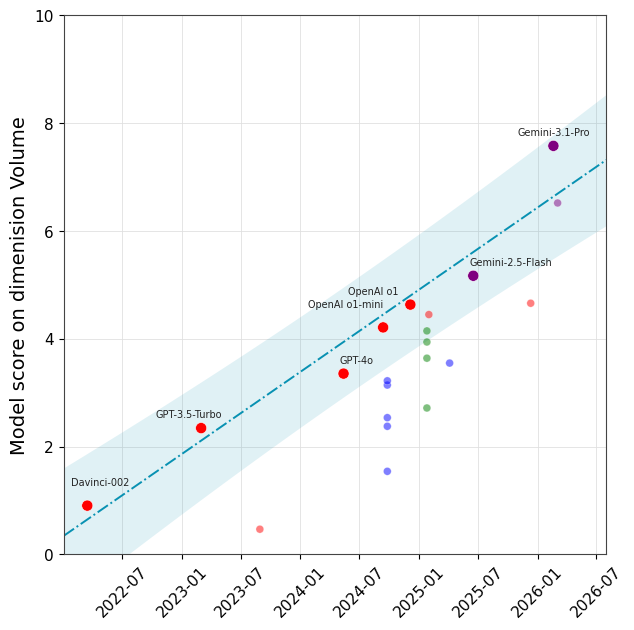

In [14]:
"""This cell generates fig 6 of our post. It also defines a few functions related to text placement on the plots"""
fig, ax = plt.subplots(1, 1, figsize=(7,7), sharex=True, sharey=True)
demand_groups = list(reduced_profiles_df.columns)
demand_groups.remove('Date')
release_dates = reduced_profiles_df['Date'].values
model_names = list(reduced_profiles_df.index)
xs = release_dates
colors = [corpo_color_map[corporations[x]] for x in model_names]

x_end = pd.Timestamp("2026-08-01")
subplot_layout_data = []

demand_group = 'VO'
ys = reduced_profiles_df[demand_group].values
front = sorted(set(frontier_indices(xs, ys)), key=lambda k: xs[k])
alphas = [1 if k in front else 0.5 for k in range(len(xs))]
sizes = [64 if k in front else 32 for k in range(len(xs))]
xsfront = [xs[k] for k in front]
ysfront = [ys[k] for k in front]
xsfront_years_since_2022 = [(x - pd.to_datetime("2022-01-01")).total_seconds() / (3600 * 24 * 365.25)
                            for x in xsfront]

ax.scatter(xs, ys, zorder=3, c=colors, alpha=alphas, s=sizes, edgecolors='white', linewidths=0.4)

# Gaussian Process regression
t_bar = np.mean(xsfront_years_since_2022)
X_front = (np.array(xsfront_years_since_2022) - t_bar).reshape(-1, 1)
y_front = np.array(ysfront)
kernel = (C(1.0, (1e-3, 1e3)) * DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3))
          + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e2)))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5, random_state=0)
gp.fit(X_front, y_front)
x_grid = np.linspace(x_lo, x_hi, 200)
y_mean, y_std = gp.predict((x_grid - t_bar).reshape(-1, 1), return_std=True)
dates_grid = [pd.to_datetime("2022-01-01") + pd.to_timedelta(x * 365.25, unit='D') for x in x_grid]

ax.plot(dates_grid, y_mean, ls='dashdot', color=COLOR_GP, lw=1.4, zorder=2)
ax.fill_between(dates_grid, y_mean - 1.96 * y_std, y_mean + 1.96 * y_std,
                color=COLOR_GP, alpha=0.12, linewidth=0, zorder=1)

ax.set_xlim(xlim)
ax.set_ylim(0, 10)
ax.set_ylabel('Model score on dimenision Volume', fontsize=14)
ax.grid(True, color='#e0e0e0', linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y')

subplot_layout_data.append({
    'ax': ax,
    'points': [(xs[k], ys[k], model_names[k]) for k in front],
    'lines_xy': [(mdates.date2num(np.array(dates_grid)), y_mean)],
    'avoid_pts': [(xs[k], ys[k]) for k in front]
})

fig.canvas.draw()

# Anti-collision placement
def _bbox(fig, ax, x_data, y_data, s, fontsize, dx_pt, dy_pt, ha, va, weight='normal'):
    x0, y0 = ax.transData.transform((mdates.date2num(x_data), y_data))
    dpi = fig.dpi
    x0 += dx_pt * dpi / 72.0
    y0 += dy_pt * dpi / 72.0
    tmp = ax.text(0, 0, s, fontsize=fontsize, fontweight=weight, alpha=0)
    renderer = fig.canvas.get_renderer()
    bb = tmp.get_window_extent(renderer=renderer)
    tmp.remove()
    w, h = bb.width, bb.height
    x_left = x0 - w / 2 if ha == 'center' else x0
    y_bottom = y0 if va == 'bottom' else y0 - h
    return mtransforms.Bbox.from_bounds(x_left, y_bottom, w, h)

def fits(bbox):
    return (ax_bbox.x0 <= bbox.x0 and bbox.x1 <= ax_bbox.x1 and ax_bbox.y0 <= bbox.y0 and bbox.y1 <= ax_bbox.y1)


def collides(bbox):
    if any(bbox.overlaps(pb) for pb in placed_boxes):
        return True
    if obstacles_pix.size and bbox.count_contains(obstacles_pix) > 0:
        return True
    return False

for data in subplot_layout_data:
    ax = data['ax']
    ax_bbox = ax.get_window_extent()

    obstacles_pix = []
    for x_arr, y_arr in data['lines_xy']:
        obstacles_pix.append(ax.transData.transform(np.column_stack([x_arr, y_arr])))
    pts_pix = (ax.transData.transform([(mdates.date2num(x), y) for x, y in data['avoid_pts']])
               if data['avoid_pts'] else np.empty((0, 2)))
    obstacles_pix = np.vstack(obstacles_pix + [pts_pix]) if obstacles_pix or pts_pix.size else np.empty((0, 2))

    placed_boxes = []

    # Place frontier model names while avoiding to superimpose them with already placed elements
    modeltextsize = 7
    for x_data, y_data, name in data['points']:
        best, fallback = None, None
        for step in range(10):
            dy = 6 + step * 7
            for dx in (0, 9, -9, 18, -18, 27, -27):
                bbox = _bbox(fig, ax, x_data, y_data, name, modeltextsize, dx, dy, ha='center', va='bottom').padded(2)
                if fits(bbox):
                    if fallback is None:
                        fallback = (dx, dy)
                    if not collides(bbox):
                        best = (dx, dy)
                        break
            if best:
                break
        dx, dy = best or fallback or (0, 6)
        ax.annotate(name, (x_data, y_data), textcoords="offset points", xytext=(dx, dy),
                    ha='center', va='bottom', fontsize=modeltextsize, color='#222222', zorder=5)
        placed_boxes.append(_bbox(fig, ax, x_data, y_data, name, modeltextsize, dx, dy, ha='center', va='bottom'))

plt.show()

In [15]:
"""Load TIMSS baselines"""
timss_adele_df = pd.read_csv("data/adele_profiles_TIMSS_G8_MaxAuxDiff=0_W=information_rho=1.csv")
timss_adele_df.drop(['SN', 'MS', 'AT'], axis=1, inplace=True) #Drop 2 NaN and 1 unreliable value.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: Converg

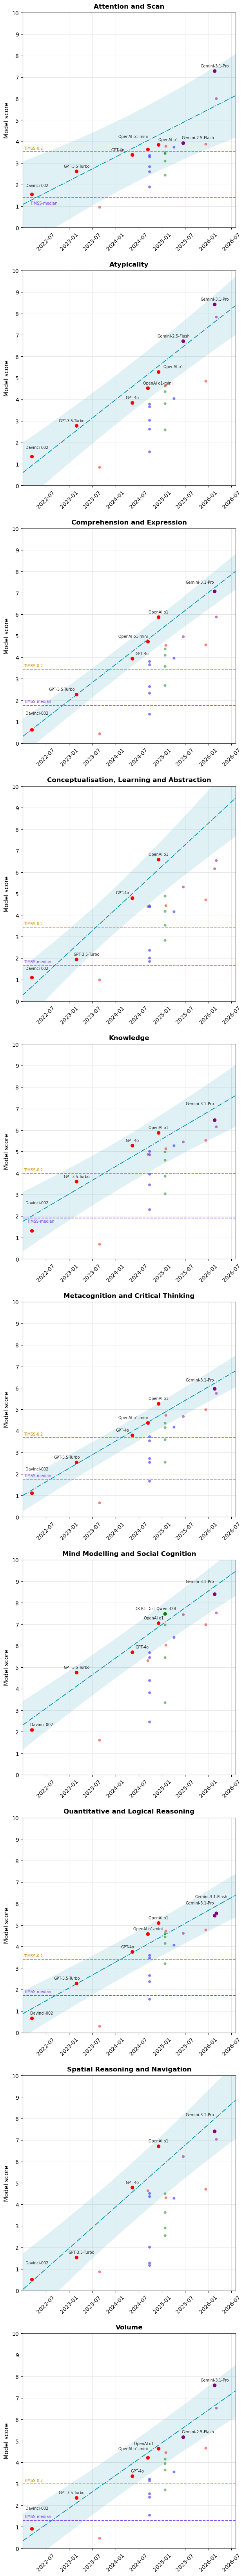

In [16]:
"""This cell draws fig 7 of our post"""
fig, axs = plt.subplots(10, 1, figsize=(7, 84), sharex=False, sharey=False)
demand_groups = list(reduced_profiles_df.columns)
demand_groups.remove('Date')
release_dates = reduced_profiles_df['Date'].values
model_names = list(reduced_profiles_df.index)
xs = release_dates
colors = [corpo_color_map[corporations[x]] for x in model_names]

subplot_layout_data = []

for i in range(10):
    ax = axs[i]
    demand_group = demand_groups[i]
    ys = reduced_profiles_df[demand_group].values
    front = sorted(set(frontier_indices(xs, ys)), key=lambda k: xs[k])
    alphas = [1 if k in front else 0.5 for k in range(len(xs))]
    sizes = [52 if k in front else 28 for k in range(len(xs))]
    xsfront = [xs[k] for k in front]
    ysfront = [ys[k] for k in front]
    xsfront_years_since_2022 = [(x - pd.to_datetime("2022-01-01")).total_seconds() / (3600 * 24 * 365.25)
                                for x in xsfront]

    ax.scatter(xs, ys, zorder=3, c=colors, alpha=alphas, s=sizes, edgecolors='white', linewidths=0.4)

    ax.set_xlim(ax.get_xlim()[0], mdates.date2num(x_end))
    xlim = ax.get_xlim()
    xlim_dates = [d.replace(tzinfo=None) for d in mdates.num2date(xlim)]
    x_lo, x_hi = [(pd.Timestamp(d) - pd.to_datetime("2022-01-01")).total_seconds() / (3600 * 24 * 365.25)
                  for d in xlim_dates]

    # TIMSS baselines
    timss_labels = []  # (x_anchor, y_anchor, text, color), to be placed later
    timss_lines_xy = []
    if demand_group in timss_adele_df.columns:
        lv20 = timss_adele_df[demand_group].iloc[0]
        ax.plot(xlim, [lv20, lv20], color=COLOR_P20, ls='--', lw=1.3, zorder=2)
        timss_labels.append((xlim_dates[0], lv20, 'TIMSS-0.2', COLOR_P20))
        timss_lines_xy.append((np.array(xlim), np.array([lv20, lv20])))

        lv50 = timss_adele_df[demand_group].iloc[1]
        ax.plot(xlim, [lv50, lv50], color=COLOR_MED, ls='--', lw=1.3, zorder=2)
        timss_labels.append((xlim_dates[0], lv50, 'TIMSS-median', COLOR_MED))
        timss_lines_xy.append((np.array(xlim), np.array([lv50, lv50])))

    # Gaussian Process regression
    t_bar = np.mean(xsfront_years_since_2022)
    X_front = (np.array(xsfront_years_since_2022) - t_bar).reshape(-1, 1)
    y_front = np.array(ysfront)
    kernel = (C(1.0, (1e-3, 1e3)) * DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3))
              + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e2)))
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5, random_state=0)
    gp.fit(X_front, y_front)
    x_grid = np.linspace(x_lo, x_hi, 200)
    y_mean, y_std = gp.predict((x_grid - t_bar).reshape(-1, 1), return_std=True)
    dates_grid = [pd.to_datetime("2022-01-01") + pd.to_timedelta(x * 365.25, unit='D') for x in x_grid]

    ax.plot(dates_grid, y_mean, ls='dashdot', color=COLOR_GP, lw=1.4, zorder=2)
    ax.fill_between(dates_grid, y_mean - 1.96 * y_std, y_mean + 1.96 * y_std,
                    color=COLOR_GP, alpha=0.12, linewidth=0, zorder=1)

    ax.set_xlim(xlim)
    ax.set_ylim(0, 10)
    ax.set_ylabel('Model score')
    ax.set_yticks(list(range(11)))
    ax.set_title(group_full_names[demand_group], pad=8)
    ax.grid(True, color='#e0e0e0', linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    subplot_layout_data.append({
        'ax': ax,
        'points': [(xs[k], ys[k], model_names[k]) for k in front],
        'lines_xy': timss_lines_xy + [(mdates.date2num(np.array(dates_grid)), y_mean)],
        'avoid_pts': [(xs[k], ys[k]) for k in front],
        'timss_labels': timss_labels,
    })

for data in subplot_layout_data:
    ax = data['ax']
    ax_bbox = ax.get_window_extent()

    obstacles_pix = []
    for x_arr, y_arr in data['lines_xy']:
        obstacles_pix.append(ax.transData.transform(np.column_stack([x_arr, y_arr])))
    pts_pix = (ax.transData.transform([(mdates.date2num(x), y) for x, y in data['avoid_pts']])
               if data['avoid_pts'] else np.empty((0, 2)))
    obstacles_pix = np.vstack(obstacles_pix + [pts_pix]) if obstacles_pix or pts_pix.size else np.empty((0, 2))

    placed_boxes = []

    # Place TIMSS labels
    for x_anchor, y_anchor, text, color in data['timss_labels']:
        best, fallback = None, None
        for dy in (3, 8, 13, -10, -15):
            for dx in (2, 8, -8, 14):
                bbox = _bbox(fig, ax, x_anchor, y_anchor, text, 7, dx, dy, ha='left', va='bottom').padded(1)
                if fits(bbox):
                    if fallback is None:
                        fallback = (dx, dy)
                    if not collides(bbox):
                        best = (dx, dy)
                        break
            if best:
                break
        dx, dy = best or fallback or (3, 3)
        ax.annotate(text, (x_anchor, y_anchor), textcoords="offset points", xytext=(dx, dy),
                    ha='left', va='bottom', fontsize=7, fontweight='normal', color=color, zorder=5)
        placed_boxes.append(_bbox(fig, ax, x_anchor, y_anchor, text, 7, dx, dy, ha='left', va='bottom'))

    # Place frontier model names
    modeltextsize = 7
    for x_data, y_data, name in data['points']:
        best, fallback = None, None
        for step in range(10):
            dy = 6 + step * 7
            for dx in (0, 9, -9, 18, -18, 27, -27):
                bbox = _bbox(fig, ax, x_data, y_data, name, modeltextsize, dx, dy, ha='center', va='bottom').padded(2)
                if fits(bbox):
                    if fallback is None:
                        fallback = (dx, dy)
                    if not collides(bbox):
                        best = (dx, dy)
                        break
            if best:
                break
        dx, dy = best or fallback or (0, 6)
        ax.annotate(name, (x_data, y_data), textcoords="offset points", xytext=(dx, dy),
                    ha='center', va='bottom', fontsize=modeltextsize, color='#222222', zorder=5)
        placed_boxes.append(_bbox(fig, ax, x_data, y_data, name, modeltextsize, dx, dy, ha='center', va='bottom'))

plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


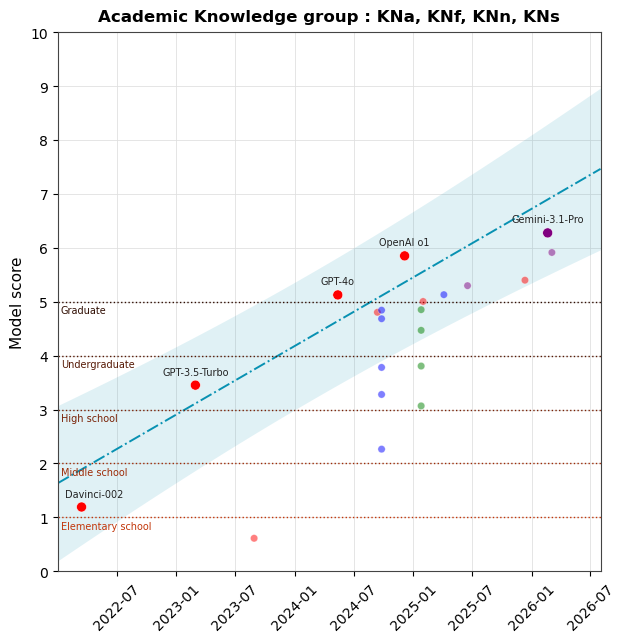

In [18]:
"""This cell draws fig 8 of our post"""
fig, ax = plt.subplots(1, 1, figsize=(7, 7), sharex=False, sharey=False)
release_dates = reduced_profiles_df['Date'].values
model_names = list(reduced_profiles_df.index)
xs = release_dates
colors = [corpo_color_map[corporations[x]] for x in model_names]

x_end = pd.Timestamp("2026-08-01")
subplot_layout_data = []

ys = ability_profiles_df[['KNa', 'KNf', 'KNn', 'KNs']].apply(hmean, axis=1).values
front = sorted(set(frontier_indices(xs, ys)), key=lambda k: xs[k])
alphas = [1 if k in front else 0.5 for k in range(len(xs))]
sizes = [52 if k in front else 28 for k in range(len(xs))]
xsfront = [xs[k] for k in front]
ysfront = [ys[k] for k in front]
xsfront_years_since_2022 = [(x - pd.to_datetime("2022-01-01")).total_seconds() / (3600 * 24 * 365.25)
                            for x in xsfront]

ax.scatter(xs, ys, zorder=3, c=colors, alpha=alphas, s=sizes, edgecolors='white', linewidths=0.4)

ax.set_xlim(ax.get_xlim()[0], mdates.date2num(x_end))
xlim = ax.get_xlim()
xlim_dates = [d.replace(tzinfo=None) for d in mdates.num2date(xlim)]
x_lo, x_hi = [(pd.Timestamp(d) - pd.to_datetime("2022-01-01")).total_seconds() / (3600 * 24 * 365.25)
              for d in xlim_dates]

# Gaussian Process regression
t_bar = np.mean(xsfront_years_since_2022)
X_front = (np.array(xsfront_years_since_2022) - t_bar).reshape(-1, 1)
y_front = np.array(ysfront)
kernel = (C(1.0, (1e-3, 1e3)) * DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3))
          + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e2)))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5, random_state=0)
gp.fit(X_front, y_front)
x_grid = np.linspace(x_lo, x_hi, 200)
y_mean, y_std = gp.predict((x_grid - t_bar).reshape(-1, 1), return_std=True)
dates_grid = [pd.to_datetime("2022-01-01") + pd.to_timedelta(x * 365.25, unit='D') for x in x_grid]

ax.plot(dates_grid, y_mean, ls='dashdot', color=COLOR_GP, lw=1.4, zorder=2)
ax.fill_between(dates_grid, y_mean - 1.96 * y_std, y_mean + 1.96 * y_std,
                color=COLOR_GP, alpha=0.12, linewidth=0, zorder=1)

ax.set_xlim(xlim)
ax.set_ylim(0, 10)
ax.set_ylabel('Model score')
ax.set_yticks(list(range(11)))
ax.set_title('Academic Knowledge group : KNa, KNf, KNn, KNs', pad=8)
ax.grid(True, color='#e0e0e0', linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', labelsize=10)

# Academic baselines
acadref_data = [
    (1.0, "Elementary school"),
    (2.0, "Middle school"),
    (3.0, "High school"),
    (4.0, "Undergraduate"),
    (5.0, "Graduate"),
]

# Choose colors that differ from the provious ones
used_colors_rgb = corpo_colors_rgb + [np.array(mcolors.to_rgb(c)) for c in (COLOR_GP, COLOR_P20, COLOR_MED)]
acadref_candidates = ['#dc2626', '#2563eb', '#16a34a', '#db2777', '#ea580c',
                   '#0f766e', '#7e22ce', '#475569']

hue_candidates = [x / 50 for x in range(20)]  # rouge->violet, pas de 30°

def gradient_from_hue(hue, n=5, l_lo=0.1, l_hi=0.4, s=0.9):
    return reversed([colorsys.hls_to_rgb(hue, l, s) for l in np.linspace(l_lo, l_hi, n)])

def min_dist_gradient(hue, refs):
    grad = gradient_from_hue(hue)
    return min(min(np.linalg.norm(np.array(c) - r) for r in refs) for c in grad) if refs else 1.0

used_colors_rgb = corpo_colors_rgb + [np.array(mcolors.to_rgb(c)) for c in (COLOR_GP, COLOR_P20, COLOR_MED)]
best_hue = max(hue_candidates, key=lambda h: min_dist_gradient(h, used_colors_rgb))
acadref_colors = [mcolors.to_hex(c) for c in gradient_from_hue(best_hue)]

x_lo_date, x_hi_date = xlim_dates[0], xlim_dates[1]
acadref_lines_xy = []
acadref_labels = []

for (y_val, name), col in zip(acadref_data, acadref_colors):
    ax.axhline(y_val, color=col, lw=1.0, ls=':', zorder=2)
    acadref_lines_xy.append((mdates.date2num(np.array([x_lo_date, x_hi_date])), np.array([y_val, y_val])))
    acadref_labels.append((x_lo_date, y_val, name, col))

subplot_layout_data.append({
    'ax': ax,
    'points': [(xs[k], ys[k], model_names[k]) for k in front],
    'lines_xy': acadref_lines_xy + [(mdates.date2num(np.array(dates_grid)), y_mean)],
    'avoid_pts': [(xs[k], ys[k]) for k in front],
    'acadref_labels': acadref_labels,
})

for data in subplot_layout_data:
    ax = data['ax']
    ax_bbox = ax.get_window_extent()

    obstacles_pix = []
    for x_arr, y_arr in data['lines_xy']:
        obstacles_pix.append(ax.transData.transform(np.column_stack([x_arr, y_arr])))
    pts_pix = (ax.transData.transform([(mdates.date2num(x), y) for x, y in data['avoid_pts']])
               if data['avoid_pts'] else np.empty((0, 2)))
    obstacles_pix = np.vstack(obstacles_pix + [pts_pix]) if obstacles_pix or pts_pix.size else np.empty((0, 2))

    placed_boxes = []

    # Place academic reference labels
    for x_anchor, y_anchor, text, color in data['acadref_labels']:
        best, fallback = None, None
        for dy in (-10, -10):
            for dx in (2, 8, -8, 14):
                bbox = _bbox(fig, ax, x_anchor, y_anchor, text, 7, dx, dy, ha='left', va='bottom').padded(1)
                if fits(bbox):
                    if fallback is None:
                        fallback = (dx, dy)
                    if not collides(bbox):
                        best = (dx, dy)
                        break
            if best:
                break
        dx, dy = best or fallback or (3, 3)
        ax.annotate(text, (x_anchor, y_anchor), textcoords="offset points", xytext=(dx, dy),
                    ha='left', va='bottom', fontsize=7, fontweight='normal', color=color, zorder=5)
        placed_boxes.append(_bbox(fig, ax, x_anchor, y_anchor, text, 7, dx, dy, ha='left', va='bottom'))

    # Place frontier model names
    modeltextsize = 7
    for x_data, y_data, name in data['points']:
        best, fallback = None, None
        for step in range(1):
            dy = 6 + step * 7
            for dx in (0, 9, -9, 18, -18, 27, -27):
                bbox = _bbox(fig, ax, x_data, y_data, name, modeltextsize, dx, dy, ha='center', va='bottom').padded(2)
                if fits(bbox):
                    if fallback is None:
                        fallback = (dx, dy)
                    if not collides(bbox):
                        best = (dx, dy)
                        break
            if best:
                break
        dx, dy = best or fallback or (0, 6)
        ax.annotate(name, (x_data, y_data), textcoords="offset points", xytext=(dx, dy),
                    ha='center', va='bottom', fontsize=modeltextsize, color='#222222', zorder=5)
        placed_boxes.append(_bbox(fig, ax, x_data, y_data, name, modeltextsize, dx, dy, ha='center', va='bottom'))

plt.show()